# **Importing**

In [ ]:
!pip install -q numpy scikit-learn
import random
import numpy as np
from collections import defaultdict, Counter
import re
!pip install unified-planning
from unified_planning.shortcuts import UserType, Fluent, BoolType, Action
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 743.5/743.5 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 14.2 MB/s eta 0:00:00


# **UPF Logging**

It will act as an impartial judge. Since if we write the code to check the plans by ourselves there's no independence.

In [ ]:
import logging

upf_logger = logging.getLogger('unified_planning')
upf_logger.setLevel(logging.INFO)

upf_file_handler = logging.FileHandler('upf_validation.log', mode='w')
upf_file_handler.setLevel(logging.INFO)

formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
upf_file_handler.setFormatter(formatter)

if not upf_logger.handlers:
    upf_logger.addHandler(upf_file_handler)

# **Class GridWorldStochastic**

This class is the simulator of the phisical world in which
the agent works

- `__init__`: builds the "world"
  - size of the grid
  - error probabilities (`slip_prob`: probability that robot moves in the wrong direction or doesn't move at all; `pick_fail_prob`: probability that the pick action doesn't work properly and the agent remains without anything within its hands;
  `drop_misplace_prob`: probability that given the position of the robot the object whitin its hands is misplaced in one of the cells around the correct one).

- `reset`: doesn't change the probabilities or the grid size. It only takes the agent and the objects and place them in the starting positions.

- `state_predicates`: maps the mathematical coordinates in logical predicates. It's the vocabulary used by the Learner to write the PDDL.

- `_get_slipped_data`: applies the move action.

- `_apply_pick`: applies the pick action.

- `_apply_drop`: applies the drop action.

- `step`: given the chosen action (move, pick, drop) applies the physical rules (so if the move is fiesable at start) and after applies the stocastical error. It returns:
  - the new logical state;
  - the boolean flag `failed_this_step`(becomes _True_ both for "legal" errors such as trying to pick a far away object and for "statistical" errors that involve legal actions on paper but followed by a malfunction in their actual implementation).






















In [ ]:
class GridWorldStochastic:
    def __init__(self, width=8, height=8, objects=None, slip_prob=0.15, pick_fail_prob=0.1, drop_misplace_prob=0.12):
        self.w = width
        self.h = height
        self.robot = (0,0)
        self.objects = objects or {}
        self.slip_prob = slip_prob
        self.pick_fail_prob = pick_fail_prob
        self.drop_misplace_prob = drop_misplace_prob

    def reset(self, robot=(0,0), objects=None):
        self.robot = robot
        if objects is not None:
            self.objects = dict(objects)
        return self.state_predicates()

    def state_predicates(self):
        preds = set()
        preds.add(f"at(robot,{self.robot})")
        has_held_object = False
        for name,pos in self.objects.items():
            if isinstance(pos, tuple) and len(pos) == 1 and pos[0] == 'held':
                preds.add(f"at({name},held)")
                preds.add(f"holding(robot,{name})")
                has_held_object = True
            else:
                preds.add(f"at({name},{pos})")
        if not has_held_object:
            preds.add("handempty")
        return preds

    def _get_slipped_delta(self, dx, dy):
        if random.random() < self.slip_prob:
            alternatives = [(1,0),(-1,0),(0,1),(0,-1),(0,0)]
            if (dx,dy) in alternatives:
                alternatives.remove((dx,dy))
            slipped_dx, slipped_dy = random.choice(alternatives)
        else:
            slipped_dx, slipped_dy = dx, dy
        return slipped_dx, slipped_dy

    def _apply_pick(self, obj):
        if self.objects.get(obj) == self.robot:
            if random.random() < self.pick_fail_prob:
                return True, False # Precondition met, but stochastic failure
            else:
                self.objects[obj] = ('held',)
                return True, True # Precondition met
        else:
            return False, False # Precondition not met

    def _apply_drop(self, obj):
        if self.objects.get(obj) == ('held',):
            if random.random() < self.drop_misplace_prob:
                deltas = [(0,0),(1,0),(-1,0),(0,1),(0,-1)]
                dx,dy = random.choice(deltas)
                new = (max(0, min(self.w-1, self.robot[0]+dx)),
                       max(0, min(self.h-1, self.robot[1]+dy)))
                self.objects[obj] = new
                return True, False # Precondition met, but stochastic failure (misplaced)
            else:
                self.objects[obj] = self.robot
                return True, True # Precondition met, perfect success
        else:
            return False, False # Precondition not met

    def step(self, action):
        failed_this_step = False

        if action[0] == "move":
            dx,dy = action[1], action[2]
            # Store original for comparison after potential slip
            original_intended_pos = (self.robot[0] + dx, self.robot[1] + dy)

            slipped_dx, slipped_dy = self._get_slipped_delta(dx, dy)

            if (slipped_dx, slipped_dy) != (dx, dy):
                failed_this_step = True

            potential_new_x = self.robot[0] + slipped_dx
            potential_new_y = self.robot[1] + slipped_dy

            if 0 <= potential_new_x < self.w and 0 <= potential_new_y < self.h:
                self.robot = (potential_new_x, potential_new_y)
            else:
                # If moved out of bounds, this is also a failure
                failed_this_step = True

        elif action[0] == "pick":
            obj = action[1]
            precondition_met, perfect_success = self._apply_pick(obj)
            if not precondition_met:
                failed_this_step = True
            elif not perfect_success:
                # Stochastic failure (pick_fail_prob)
                failed_this_step = True

        elif action[0] == "drop":
            obj = action[1]
            robot_current_pos = self.robot # Store robot's position before drop

            precondition_met, _ = self._apply_drop(obj)

            if not precondition_met:
                failed_this_step = True
            else:
                final_obj_pos = self.objects.get(obj)
                if final_obj_pos != robot_current_pos:
                    failed_this_step = True

        return self.state_predicates(), failed_this_step

def pretty(s):
    return "{" + ", ".join(sorted(s)) + "}"

# **Class MiniActionModelLearner**

- `__init__ ` sets all the structures to save all that will happen (how many times an action succeds/fails, which are the preconditions/effects). It saves three important parameters:
  - `pre_thresh` defines the percentage of times that a condition (or predicate $p$) must be present in the initial state ($s$) before a successful action ($a_s$) to be considered a precondition: $P(p \in s \mid a_s) \ge \text{pre_thresh}$,

  - `eff_tresh` defines:
    - a percentage of times that a condition (or predicate $p$) must appear after a successful action ($a_s$) to be considered an additive effect (intended as a novelty relative to the initial state $(s' \setminus s)$): $P(p \in (s' \setminus s) \mid a_s) \ge \text{eff_thresh}$
    - a percentage of times that a condition (or predicate $p$) must disappear after a successful action ($a_s$) to be considered a subtractive effect (intended as that which has not survived from the initial state $(s \setminus s')$): $P(p \in (s \setminus s') \mid a_s) \ge \text{eff_thresh}$
  - `min_support` defines the minimum sample size of successful executions $(N(a_s))$ required for a certain action in order to evaluate its preconditions and effects (i.e., to perform statistical inference): $N(a_s) \ge \text{min\_support}$.

- `observe_transition` processes raw observations to update empirical counts:
  - Filter: If the action fails, it updates fail_counts and exits, ensuring statistics are conditioned on success ($a_s$).
  - Log: Saves the transition in state_history for the future recovery of masked predicates (Inertia).
  - Counter: Increments the total successes $N(a_s)$ and the frequencies of preconditions ($s$), additive effects $(s' \setminus s)$, and subtractive effects $(s \setminus s')$.

In [ ]:
import random
import numpy as np
from collections import defaultdict, Counter

class MiniActionModelLearner:
    def __init__(self, pre_thresh=0.8, eff_thresh=0.15, min_support=5):
        self.state_history = []
        self.pre_examples = defaultdict(list)
        self.eff_pos_counts = defaultdict(Counter)
        self.eff_neg_counts = defaultdict(Counter)
        self.sa_counts = Counter()
        self.fail_counts = defaultdict(int)
        self.pre_thresh = pre_thresh
        self.eff_thresh = eff_thresh
        self.min_support = min_support

    def observe_transition(self, s_obs, action, s_next_obs, failed=False):
        op = action[0] if isinstance(action, (tuple,list)) else action
        s_obs = set(s_obs)
        s_next_obs = set(s_next_obs)

        self.state_history.append((s_obs, action, s_next_obs, failed))

        if failed:
            self.fail_counts[op] += 1
            return

        self.sa_counts[op] += 1
        self.pre_examples[op].append(s_obs)
        for a in s_next_obs - s_obs:
            self.eff_pos_counts[op][a] += 1
        for a in s_obs - s_next_obs:
            self.eff_neg_counts[op][a] += 1

    def compute_preconditions(self):
        pre = {}
        for op, examples in self.pre_examples.items():
            total_successes = self.sa_counts[op]
            if total_successes < self.min_support:
                pre[op] = set()
                continue

            atom_counts = Counter()
            for state in examples:
                for atom in state:
                    atom_counts[atom] += 1

            pre[op] = {atom for atom, count in atom_counts.items()
                       if (count / total_successes) >= self.pre_thresh}
        return pre

    def compute_effect_probabilities(self):
        eff_probs = {}
        for op, total_successes in self.sa_counts.items():
            if total_successes == 0: continue

            add_probs = {atom: cnt/total_successes for atom, cnt in self.eff_pos_counts[op].items()
                         if (cnt/total_successes) >= self.eff_thresh}
            del_probs = {atom: cnt/total_successes for atom, cnt in self.eff_neg_counts[op].items()
                         if (cnt/total_successes) >= self.eff_thresh}

            eff_probs[op] = {
                'add': add_probs,
                'del': del_probs,
                'count': total_successes + self.fail_counts[op],
                'fails': self.fail_counts[op]
            }
        return eff_probs

    def apply_inertia(self):
        eff_probs = self.compute_effect_probabilities()

        def get_sig(atom_str):
            if '(' in atom_str and atom_str.endswith(')'):
                idx = atom_str.index('(')
                pred = atom_str[:idx]
                inside = atom_str[idx+1:-1].strip()
                first_arg = inside.split(',')[0].strip()
                return f"{pred}_{first_arg}"
            return atom_str

        completed = []
        for (s, a, sn, failed) in self.state_history:
            op = a[0]
            s_comp = set(s)
            sn_comp = set(sn)

            official_add = eff_probs.get(op, {}).get('add', {})
            official_del = eff_probs.get(op, {}).get('del', {})

            disappeared = {atom for atom in s if atom not in sn and atom not in official_del}
            appeared = {atom for atom in sn if atom not in s and atom not in official_add}

            disappeared_sigs = {get_sig(atom) for atom in disappeared}
            appeared_sigs = {get_sig(atom) for atom in appeared}

            for atom in disappeared:
                if get_sig(atom) not in appeared_sigs:
                    sn_comp.add(atom)

            for atom in appeared:
                if get_sig(atom) not in disappeared_sigs:
                    s_comp.add(atom)

            completed.append((s_comp, a, sn_comp, failed))

        return completed

# **infer_parametric_operators_from_history**

This function learns general rules (PDDL operators) for actions like 'move', 'pick', and 'drop' by analyzing a history of observations.

### **Purpose:**

The goal is to transform specific observed events (e.g., 'robot at (1,2) moved to (1,3)') into abstract, general rules (e.g., 'When the robot is at *any* location `?x ?y` and moves, it goes to a *new* location `?new_x ?new_y`'). This allows the robot to understand and apply rules broadly, not just for specific instances.

### **Key Inputs:**

- `state_history`: A sequence of robot transitions, each containing the starting state, action taken, ending state, and whether the action failed.
- `effect_prob_threshold`: A probability threshold to decide if a change (predicate appearing or disappearing) is a true 'effect' of an action.
- `precondition_prob_threshold`: A probability threshold to determine if a predicate must be true *before* an action for it to be a 'precondition'.
- `min_precondition_support`: The minimum number of successful times an action must occur to consider learning its rules.

### **How it works:**

1.  **Filter Successes:** Only successful action executions are considered for learning, grouped by action type.
2.  **Lift to Generality:** Concrete entities and coordinates (e.g., `at(robot, 1, 2)`) are replaced with general variables (e.g., `at(?robot, ?x, ?y)`). This process identifies shared patterns.
    - **Role of `parse_atom`:** To do this 'lifting', the `parse_atom` helper function is crucial. It takes a raw predicate string (like `at(robot,1,2)` or `holding(robot,box)`) and breaks it down into its core components: the predicate name (`at`, `holding`) and its arguments (`robot`, `1`, `2`). This structured format allows the function to easily identify constants (like `robot`, `box`) and numerical coordinates, which are then replaced by generalized variables (like `?robot`, `?obj`, `?x`, `?y`).
3.  **Count Frequencies:** The function counts how often each generalized precondition, added effect, or deleted effect appears across all successful examples for an action.
4.  **Apply Thresholds:** These counts are then compared against `precondition_prob_threshold` and `effect_prob_threshold` to filter out infrequent or unreliable patterns, keeping only the most significant ones.
5.  **Identify Action Parameters:** All unique variables (like `?robot`, `?obj`, `?x`, `?y`) used in the filtered preconditions and effects are collected as action parameters.
6.  **Formulate Operator:** Finally, the function constructs a PDDL-like operator for each action, including its parameters, preconditions, and effects (both added and deleted).

### **Output:**

A set of structured, general PDDL rules for each action.

In [ ]:
def infer_parametric_operators_from_history(state_history, effect_prob_threshold=0.2, precondition_prob_threshold=0.8, min_precondition_support=5):
    ops = defaultdict(list)
    for (s, a, sn, failed) in state_history:
        if failed: continue
        action_key = a[0]
        ops[action_key].append((s, a, sn))

    results = {}
    for op_key, trans in ops.items():
        all_lifted_pre = []
        all_lifted_add = []
        all_lifted_del = []

        for (s, a, sn) in trans:
            adds = sn - s
            dels = s - sn
            pres = s

            action_name = a[0]
            action_target_obj_name = a[1] if len(a) > 1 and action_name in ["pick", "drop"] else None

            robot_at_s = None
            obj_at_s = None
            robot_at_sn = None
            obj_at_sn = None

            if action_target_obj_name:
                for atom_str in s:
                    pred, args = parse_atom(atom_str)
                    if pred == 'at':
                        if args[0] == 'robot' and len(args) == 3:
                            robot_at_s = (int(args[1]), int(args[2]))
                        elif args[0] == action_target_obj_name and len(args) == 3:
                            obj_at_s = (int(args[1]), int(args[2]))

                for atom_str in sn:
                    pred, args = parse_atom(atom_str)
                    if pred == 'at':
                        if args[0] == 'robot' and len(args) == 3:
                            robot_at_sn = (int(args[1]), int(args[2]))
                        elif args[0] == action_target_obj_name and len(args) == 3:
                            obj_at_sn = (int(args[1]), int(args[2]))

            robot_pre_coord_map = {}
            robot_pre_coord_counters = defaultdict(int)
            obj_pre_coord_map = {}
            obj_pre_coord_counters = defaultdict(int)
            other_pre_var_map = {}
            other_pre_var_counters = defaultdict(int)

            robot_suc_coord_map = {}
            robot_suc_coord_counters = defaultdict(int)
            obj_suc_coord_map = {}
            obj_suc_coord_counters = defaultdict(int)
            other_suc_var_map = {}
            other_suc_var_counters = defaultdict(int)

            shared_pick_pre_coord_map = {}
            shared_pick_pre_coord_counters = defaultdict(int)

            shared_drop_coords_map = {}
            shared_drop_coords_counters = defaultdict(int)


            def lift_atoms_internal(atom_set, is_successor_state):
                lifted = set()

                current_robot_coord_map = robot_suc_coord_map if is_successor_state else robot_pre_coord_map
                current_robot_coord_counters = robot_suc_coord_counters if is_successor_state else robot_pre_coord_counters
                current_obj_coord_map = obj_suc_coord_map if is_successor_state else obj_pre_coord_map
                current_obj_coord_counters = obj_suc_coord_counters if is_successor_state else obj_pre_coord_counters
                current_other_var_map = other_suc_var_map if is_successor_state else other_pre_var_map
                current_other_var_counters = other_suc_var_counters if is_successor_state else other_pre_var_counters

                for atom in sorted(atom_set, reverse=True):
                    pred, args = parse_atom(atom)
                    if not args:
                        lifted.add((pred, ()))
                        continue

                    l_args = []
                    entity_name_constant = args[0]

                    if entity_name_constant == 'robot':
                        l_args.append('?robot')
                    elif action_target_obj_name is not None and entity_name_constant == action_target_obj_name:
                        l_args.append('?obj')
                    else:
                        key = ('obj_name', entity_name_constant)
                        if key not in current_other_var_map:
                            current_other_var_counters['obj_name'] += 1
                            current_other_var_map[key] = f"?other_obj{current_other_var_counters['obj_name']}"
                        l_args.append(current_other_var_map[key])

                    if pred == 'at':
                        if len(args) == 3:
                            coord_x_val = int(args[1])
                            coord_y_val = int(args[2])

                            map_dict_for_coords = None
                            counters_dict_for_coords = None
                            x_prefix = ""
                            y_prefix = ""

                            if (not is_successor_state and action_name == "pick" and
                                robot_at_s is not None and obj_at_s is not None and
                                robot_at_s == obj_at_s and robot_at_s == (coord_x_val, coord_y_val)):
                                map_dict_for_coords = shared_pick_pre_coord_map
                                counters_dict_for_coords = shared_pick_pre_coord_counters
                                x_prefix = "?x"
                                y_prefix = "?y"
                            elif action_name == "drop":
                                if is_successor_state and entity_name_constant == action_target_obj_name and \
                                   robot_at_sn is not None and obj_at_sn is not None and \
                                   robot_at_sn == obj_at_sn and robot_at_sn == (coord_x_val, coord_y_val):
                                    map_dict_for_coords = shared_drop_coords_map
                                    counters_dict_for_coords = shared_drop_coords_counters
                                    x_prefix = "?x"
                                    y_prefix = "?y"
                                elif not is_successor_state and entity_name_constant == 'robot' and \
                                     robot_at_s is not None and robot_at_s == (coord_x_val, coord_y_val):
                                    map_dict_for_coords = shared_drop_coords_map
                                    counters_dict_for_coords = shared_drop_coords_counters
                                    x_prefix = "?x"
                                    y_prefix = "?y"

                            if map_dict_for_coords is None:
                                if entity_name_constant == 'robot':
                                    map_dict_for_coords = current_robot_coord_map
                                    counters_dict_for_coords = current_robot_coord_counters
                                    x_prefix = "?new_rx" if is_successor_state else "?rx"
                                    y_prefix = "?new_ry" if is_successor_state else "?ry"
                                else:
                                    map_dict_for_coords = current_obj_coord_map
                                    counters_dict_for_coords = current_obj_coord_counters
                                    x_prefix = "?new_ox" if is_successor_state else "?ox"
                                    y_prefix = "?new_oy" if is_successor_state else "?oy"

                            key_x = ('coord_x', coord_x_val)
                            if key_x not in map_dict_for_coords:
                                counters_dict_for_coords['coord_x'] += 1
                                map_dict_for_coords[key_x] = f"{x_prefix}{counters_dict_for_coords['coord_x']}"
                            l_args.append(map_dict_for_coords[key_x])

                            key_y = ('coord_y', coord_y_val)
                            if key_y not in map_dict_for_coords:
                                counters_dict_for_coords['coord_y'] += 1
                                map_dict_for_coords[key_y] = f"{y_prefix}{counters_dict_for_coords['coord_y']}"
                            l_args.append(map_dict_for_coords[key_y])

                        elif len(args) == 2 and args[1] == 'held':
                            l_args.append('held')
                        else:
                            l_args.extend(args[1:])

                    elif pred == 'holding':
                        obj_arg_constant = args[1]
                        if action_target_obj_name is not None and obj_arg_constant == action_target_obj_name:
                            l_args.append("?obj")
                        else:
                            key = ('obj_name', obj_arg_constant)
                            if key not in current_other_var_map:
                                current_other_var_counters['obj_name'] += 1
                                current_other_var_map[key] = f"?other_obj{current_other_var_counters['obj_name']}"
                            l_args.append(current_other_var_map[key])
                    else:
                        l_args.extend(args[1:])

                    lifted.add((pred, tuple(l_args)))
                return lifted

            abs_pres = lift_atoms_internal(pres, False)
            abs_dels = lift_atoms_internal(dels, False)
            abs_adds = lift_atoms_internal(adds, True)

            all_lifted_pre.append(abs_pres)
            all_lifted_add.append(abs_adds)
            all_lifted_del.append(abs_dels)

        total = len(trans)
        if total < min_precondition_support:
            results[op_key] = {'params': [], 'pre': [], 'add': [], 'del': []}
            continue

        pre_counts = Counter()
        for p_set in all_lifted_pre:
            for atom in p_set: pre_counts[atom] += 1

        final_pre = []
        for atom, count in pre_counts.items():
            frequency = count / total
            if frequency >= precondition_prob_threshold:
                final_pre.append((atom, frequency))

        if op_key == 'move':
            filtered_move_pre = []
            for (pred, args), freq in final_pre:
                if pred == 'at' and '?robot' == args[0] and len(args) == 3:
                    filtered_move_pre.append(((pred, args), freq))
            final_pre = filtered_move_pre


        add_counts = Counter()
        for a_set in all_lifted_add:
            for atom in a_set: add_counts[atom] += 1
        final_add = [(atom, count/total) for atom, count in add_counts.items() if count / total >= effect_prob_threshold]

        del_counts = Counter()
        for d_set in all_lifted_del:
            for atom in d_set: del_counts[atom] += 1
        final_del = [(atom, count/total) for atom, count in del_counts.items() if count / total >= effect_prob_threshold]

        params = set()
        if op_key == 'move':
            params.add('?dx')
            params.add('?dy')

        if op_key in ["pick", "drop"]:
            params.add('?obj')

        params.add('?robot')

        for (pred, args), _ in final_pre + final_add + final_del:
            for arg in args:
                if isinstance(arg, str) and arg.startswith('?'):
                    params.add(arg)

        results[op_key] = {
            'params': sorted(list(params)),
            'pre': sorted(final_pre, key=lambda x: str(x[0])),
            'add': sorted(final_add, key=lambda x: str(x[0])),
            'del': sorted(final_del, key=lambda x: str(x[0]))
        }

    return results

In [ ]:
def parse_atom(atom):
    atom = atom.strip()
    if '(' not in atom or not atom.endswith(')'):
        return atom, []
    idx = atom.index('(')
    pred = atom[:idx]
    inside = atom[idx+1:-1].strip()
    args, depth, cur = [], 0, ''
    for ch in inside:
        if ch == ',' and depth == 0:
            args.append(cur.strip()); cur = ''
        else:
            cur += ch
            if ch == '(': depth += 1
            elif ch == ')': depth -= 1
    if cur.strip() != '':
        args.append(cur.strip())

    final_args = []
    for a in args:
        a = a.strip()
        if a.startswith('(') and a.endswith(')'):
            inner = a[1:-1].strip()
            parts = [p.strip() for p in inner.split(',') if p.strip() != '']
            final_args.extend(parts)
        else:
            final_args.append(a)
    return pred, final_args

def print_parametric_pddl(ops_info, eff_probs=None, effect_display_prob_threshold=0.2):
    for op_key, info in ops_info.items():
        action_name_str = op_key

        print("\n" + "="*50)
        print(f"(:action {action_name_str}")
        params = " ".join(info['params'])
        print(f" :parameters ({params})")

        print(" :precondition (and")
        for (pred, args), p in info['pre']:
            print(f"    ; p={p:.2f}")
            print("    (" + pred + (" " + " ".join(args) if args else "") + ")")
        print(" )")

        print(" :effect (and")
        for (pred, args), p in info['add']:
            print(f"    ; p={p:.2f}")
            print("    (" + pred + (" " + " ".join(args) if args else "") + ")")
        for (pred, args), p in info['del']:
            print(f"    ; p={p:.2f}")
            print("    (not (" + pred + (" " + " ".join(args) if args else "") + "))")
        print(" )")
        print(")")

# **run_experiment Function**

This function orchestrates a single learning experiment. It sets up the simulated environment, controls the interaction between the agent and the environment, and collects data for the `MiniActionModelLearner`.

### **Purpose:**

To simulate the robot's learning process under specific conditions (noise levels, learning thresholds, number of episodes) and evaluate how well it infers PDDL operators for 'move', 'pick', and 'drop' actions.

### **Key Parameters:**

- `slip_prob`: Probability of robot movement errors.
- `pick_fail_prob`: Probability of failure when picking an object.
- `drop_misplace_prob`: Probability of misplacing an object during a drop.
- `mask_prob`: Probability of sensor noise, leading to predicates being 'masked' (hidden).
- `episodes`: Number of random interaction steps in the environment.
- `pre_thresh`: Precondition probability threshold for the learner.
- `eff_thresh`: Effect probability threshold for the learner.
- `seed`: Random seed for reproducibility.
- `manual_plan_executions`: Number of times pre-defined plans are executed to ensure sufficient data for 'pick' and 'drop' actions.

### **How it works:**

1.  **Initialization:**
    - Sets random seeds for reproducibility if `seed` is provided.
    - Creates an instance of `GridWorldStochastic` (the environment simulator) with specified noise levels.
    - Creates an instance of `MiniActionModelLearner` with specified learning thresholds (`pre_thresh`, `eff_thresh`).

2.  **Manual Plan Execution (Initial Data Gathering):**
    - Executes a set of pre-defined `MANUAL_PLANS` multiple times (`manual_plan_executions`).
    - These plans ensure that the learner observes a baseline number of successful 'pick' and 'drop' actions, which are less frequent in purely random exploration.
    - For each step in a plan:
        - Observes the current state (`s_obs`), potentially with sensor noise (`mask_prob`).
        - Executes the action in the `GridWorldStochastic` environment, which applies physical rules and stochastic errors (`stochastic_failed`).
        - Observes the next state (`s2_obs`), again with potential sensor noise.
        - Records the transition (`s_obs`, `action`, `s2_obs`, `stochastic_failed`) in the `learner`.

3.  **Random Exploration (Main Learning Loop):**
    - Runs for a specified number of `episodes`.
    - Periodically resets the environment to a new starting variant to encourage diverse experiences.
    - In each episode:
        - Observes the current state (`s_obs`).
        - Selects an action: primarily 'move' actions, but also attempts 'pick' or 'drop' actions with a certain `PICK_DROP_CONSIDERATION_PROB` if their preconditions are met.
        - Simulates the action in the environment and records the transition, similar to the manual plan execution phase.

4.  **Operator Inference:**
    - After all interactions, `learner.compute_effect_probabilities()` is called to gather statistics on effects.
    - `learner.apply_inertia()` is used to refine the observed history by applying the inertia principle (unobserved predicates tend to persist).
    - `infer_parametric_operators_from_history()` is called with the smoothed history and learning thresholds to infer the generalized PDDL operators.

### **Output:**

Returns the `learner` instance, the inferred `ops_info` (parametric PDDL operators), and `eff_probs` (raw effect probabilities and counts).

In [ ]:
def run_experiment(slip_prob=0.15, pick_fail_prob=0.1, drop_misplace_prob=0.1,
                   mask_prob=0.12, episodes=400, pre_thresh=0.8, eff_thresh=0.15, seed=None, manual_plan_executions=6,
                   reset_env_interval=25):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    env = GridWorldStochastic(width=4, height=4, objects={'box':(2,1)},
                              slip_prob=slip_prob, pick_fail_prob=pick_fail_prob,
                              drop_misplace_prob=drop_misplace_prob)

    learner = MiniActionModelLearner(pre_thresh=pre_thresh, eff_thresh=eff_thresh)

    variants = [
        {'robot':(0,0), 'objects':{'box':(2,1)}},
        {'robot':(1,1), 'objects':{'box':(1,1)}},
        {'robot':(2,0), 'objects':{'box':(2,0)}},
        {'robot':(3,3), 'objects':{'box':(3,2)}},
    ]

    MANUAL_PLANS = [
        [('move',1,0), ('move',1,0), ('pick','box'), ('move',-1,0), ('drop','box')],
        [('move',0,1), ('move',1,0), ('pick','box'), ('move',0,-1), ('drop','box')],
        [('pick','box'), ('move',1,0), ('move',0,1), ('move',-1,0), ('move',0,-1), ('drop','box')]
    ]

    for plan in MANUAL_PLANS:
        for _ in range(manual_plan_executions):
            v = random.choice(variants)
            env.reset(robot=v['robot'], objects=v['objects'])
            for action in plan:
                s = env.state_predicates()
                s_obs = set(p for p in s if random.random() > mask_prob)

                action_valid_for_env_step = True
                if action[0] == "pick":
                    if env.objects.get(action[1]) != env.robot:
                        action_valid_for_env_step = False
                elif action[0] == "drop":
                    if env.objects.get(action[1]) != ('held',):
                        action_valid_for_env_step = False

                s2_actual = s
                stochastic_failed = False

                if action_valid_for_env_step:
                    s2_actual, stochastic_failed = env.step(action)
                    s2_obs = set(p for p in s2_actual if random.random() > mask_prob)
                    learner.observe_transition(s_obs, action, s2_obs, failed=stochastic_failed)
                else:
                    pass

    moves = [("move",1,0),("move",-1,0),("move",0,1),("move",0,-1),("move",0,0)]
    PICK_DROP_CONSIDERATION_PROB = 0.8

    for ep in range(episodes):
        if ep % reset_env_interval == 0:
            v = random.choice(variants)
            env.reset(robot=v['robot'], objects=v['objects'])
        s = env.state_predicates()
        s_obs = set(p for p in s if random.random() > mask_prob)

        candidates = list(moves)

        can_pick = env.objects.get('box') == env.robot
        can_drop = env.objects.get('box') == ('held',)

        if can_pick and random.random() < PICK_DROP_CONSIDERATION_PROB:
            candidates.append(("pick","box"))
        if can_drop and random.random() < PICK_DROP_CONSIDERATION_PROB:
            candidates.append(("drop","box"))

        action = random.choice(candidates)

        s2_actual, stochastic_failed = env.step(action)
        s2_obs = set(p for p in s2_actual if random.random() > mask_prob)
        learner.observe_transition(s_obs, action, s2_obs, failed=stochastic_failed)

    eff_probs = learner.compute_effect_probabilities()

    smoothed_history = learner.apply_inertia()

    ops_info = infer_parametric_operators_from_history(
        smoothed_history,
        effect_prob_threshold=eff_thresh,
        precondition_prob_threshold=pre_thresh,
        min_precondition_support=5
    )
    return learner, ops_info, eff_probs

## **check_pddl_inference and run_iterative_experiment_for_scenarios Functions**

### **`check_pddl_inference`**

This function is an independent semantic validator based on the *Unified Planning Framework (UPF)*. Its purpose is to convert the inferred data for a PDDL operator into a UPF action and verify its structural consistency. In other words, it acts as an impartial "judge" to determine if the properties (preconditions, effects) inferred for an action make logical sense according to PDDL rules.

#### **How it works:**

1.  **Structural Validation**: Takes the operator name (e.g., 'move', 'pick', 'drop') and the inferred data (`op_data`, which contains parameters, preconditions, and effects) as input.
2.  **Conversion to UPF**: Converts PDDL atoms (e.g., `at(robot, ?x, ?y)`) into UPF Fluents and Actions.
3.  **Specific Checks**: Performs specific checks for each action type ('move', 'pick', 'drop'):
    *   **`move`**: Verifies that there is a single precondition and a single add/delete effect for the robot's position, and that the 'at a position' precondition becomes 'not at that position' and 'at a new position'.
    *   **`pick`**: Checks spatial consistency, i.e., that the robot and the object are in the same position before the action.
    *   **`drop`**: Checks spatial consistency, i.e., that the object ends up in the same position as the robot after the action.
4.  **Logging**: Every comparison and validation result is logged in the `upf_validation.log` file for traceability.

#### **Output:**

Returns `True` if the inferred operator is semantically valid according to PDDL rules and specific action checks, otherwise `False`.

### **`run_iterative_experiment_for_scenarios`**

This function orchestrates the execution of iterative experiments for a series of predefined scenarios. The goal is to determine how many manual plan executions are needed to successfully infer all PDDL operators (`move`, `pick`, `drop`) under different noise and visibility conditions.

#### **How it works:**

1.  **Scenario Iteration**: For each scenario in the `scenarios` list:
    *   A manual execution counter (`current_manual_executions`) is initialized.
    *   An iteration loop starts (up to `max_iterations`).
2.  **`run_experiment` Execution**: In each iteration, the `run_experiment` function (described in the previous block) is called with the scenario-specific parameters and the current number of manual executions.
3.  **Inference Check**: After each `run_experiment` execution, `check_pddl_inference` is used to verify if 'move', 'pick', and 'drop' operators have been successfully inferred.
4.  **Increment and Convergence**: If not all operators are inferred, the number of manual executions is increased (`increment_by`), and the experiment is repeated.
5.  **Result Storage**: Detailed results of each iteration are collected for each scenario, including the number of manual executions, the inference status of each operator, and effect statistics.

#### **Output:**

Returns a dictionary (`all_results`) containing the complete results for each scenario, including the final `learner`, inferred `ops_info`, `eff_probs`, and the number of manual executions required to achieve convergence.

### **`display_detailed_inference_results`**

This function displays the detailed inference results for each scenario in a Pandas DataFrame, providing a clear table of iteration-wise inference status and execution counts for 'move', 'pick', and 'drop' actions.

In [ ]:
def check_pddl_inference(ops_info, action_name)
    op_data = ops_info.get(action_name)
    if not op_data:
        return False
    return bool(op_data['params']) and bool(op_data['pre']) and bool(op_data['add']) and bool(op_data['del'])

def run_iterative_experiment_for_scenarios(scenarios, max_iterations=10, initial_executions=1, increment_by=5):
    """
    Runs the experiment iteratively for each scenario, increasing manual plan executions
    until 'pick' and 'drop' operators are inferred or max_iterations is reached.
    """
    all_results = {}
    for scenario_config in scenarios:
        scenario_name = scenario_config['name']
        scenario_params = scenario_config['params']
        print(f"\n===== Running Iterative Experiment for Scenario: {scenario_name} ====")
        print(f" Parameters: {scenario_params}")

        current_manual_executions = initial_executions
        scenario_learner = None
        scenario_ops_info = None
        scenario_eff_probs = None
        scenario_success = False
        detailed_inference_results = []

        for i in range(max_iterations):

            print(f"\n--- Iteration {i+1}/{max_iterations} with {current_manual_executions} manual plan executions ---")
            combined_params = {**scenario_params, 'manual_plan_executions': current_manual_executions, 'seed': 42}
            learner, ops_info, eff_probs = run_experiment(**combined_params)

            print("  --- Action Statistics for this Iteration ---")
            for action_name, stats in eff_probs.items():
                total_count = stats.get('count', 0)
                fail_count = stats.get('fails', 0)
                success_count = total_count - fail_count
                print(f"    Action '{action_name}': Executions={total_count}, Successes={success_count}, Failures={fail_count}")
            print("  ---------------------------------------------")

            pick_inferred = check_pddl_inference(ops_info, 'pick')
            drop_inferred = check_pddl_inference(ops_info, 'drop')
            move_inferred = check_pddl_inference(ops_info, 'move')

            print(f"'pick' inferred: {pick_inferred}")
            print(f"'drop' inferred: {drop_inferred}")
            print(f"'move' inferred: {move_inferred}")

            detailed_inference_results.append({
                'iteration': i + 1,
                'manual_executions': current_manual_executions,
                'move_inferred': move_inferred,
                'pick_inferred': pick_inferred,
                'drop_inferred': drop_inferred,
                'eff_probs': eff_probs
            })

            if pick_inferred and drop_inferred and move_inferred:
                print(f"All required operators successfully inferred for {scenario_name}! Stopping iteration.")
                scenario_learner = learner
                scenario_ops_info = ops_info
                scenario_eff_probs = eff_probs
                scenario_success = True
                break
            current_manual_executions += increment_by

        if not scenario_success:
            print(f"Max iterations reached for {scenario_name}. 'pick', 'drop' or 'move' not fully inferred.")
            scenario_learner = learner
            scenario_ops_info = ops_info
            scenario_eff_probs = eff_probs

        all_results[scenario_name] = {
            'learner': scenario_learner,
            'ops_info': scenario_ops_info,
            'eff_probs': scenario_eff_probs,
            'manual_executions_used': current_manual_executions if scenario_success else 'Max iterations reached',
            'params': scenario_params,
            'detailed_inference_results': detailed_inference_results
        }
    return all_results

test_scenarios = [
    {
        "name": "1. Ideal Baseline (Deterministic, 100% Visibility)",
        "params": {"slip_prob": 0.0, "pick_fail_prob": 0.0, "drop_misplace_prob": 0.0,
                   "mask_prob": 0.0, "episodes": 500, "pre_thresh": 0.6, "eff_thresh": 0.15}
    },
    {
        "name": "2. High Environmental Noise (40% Action Failure)",
        "params": {"slip_prob": 0.4, "pick_fail_prob": 0.4, "drop_misplace_prob": 0.4,
                   "mask_prob": 0.1, "episodes": 500, "pre_thresh": 0.8, "eff_thresh": 0.15}
    },
    {
        "name": "3. Low Visibility (40% Sensor Blindness)",
        "params": {"slip_prob": 0.1, "pick_fail_prob": 0.1, "drop_misplace_prob": 0.1,
                   "mask_prob": 0.4, "episodes": 500, "pre_thresh": 0.6, "eff_thresh": 0.30}
    },
    {
        "name": "4. Low Exploration (Only 50 Episodes)",
        "params": {"slip_prob": 0.15, "pick_fail_prob": 0.1, "drop_misplace_prob": 0.1,
                   "mask_prob": 0.1, "episodes": 50, "pre_thresh": 0.8, "eff_thresh": 0.15}
    }
]

all_scenario_results = run_iterative_experiment_for_scenarios(test_scenarios, initial_executions=20, increment_by=10)

print("\n--- Final Inferred PDDL Operators for All Scenarios ---")
for scenario_name, results in all_scenario_results.items():
    print(f"\nScenario: {scenario_name}")
    print(f" Parameters: {results['params']}")
    print(f"Manual Executions Used to Infer Pick/Drop/Move: {results['manual_executions_used']}")
    print_parametric_pddl(results['ops_info'])


===== Running Iterative Experiment for Scenario: 1. Ideal Baseline (Deterministic, 100% Visibility) ====
 Parameters: {'slip_prob': 0.0, 'pick_fail_prob': 0.0, 'drop_misplace_prob': 0.0, 'mask_prob': 0.0, 'episodes': 500, 'pre_thresh': 0.6, 'eff_thresh': 0.15}

--- Iteration 1/10 with 20 manual plan executions ---
  --- Action Statistics for this Iteration ---
    Action 'move': Executions=684, Successes=552, Failures=132
    Action 'pick': Executions=21, Successes=21, Failures=0
    Action 'drop': Executions=19, Successes=19, Failures=0
  ---------------------------------------------
'pick' inferred: True
'drop' inferred: True
'move' inferred: True
All required operators successfully inferred for 1. Ideal Baseline (Deterministic, 100% Visibility)! Stopping iteration.

===== Running Iterative Experiment for Scenario: 2. High Environmental Noise (40% Action Failure) ====
 Parameters: {'slip_prob': 0.4, 'pick_fail_prob': 0.4, 'drop_misplace_prob': 0.4, 'mask_prob': 0.1, 'episodes': 500,

In [ ]:
import pandas as pd

def display_detailed_inference_results(all_scenario_results):
    for scenario_name, results in all_scenario_results.items():
        print(f"\n--- Dettaglio Inferenza per Iterazione - Scenario: {scenario_name} ---")

        detailed_data = []
        for iteration_result in results['detailed_inference_results']:
            detailed_data.append({
                'Iterazione': iteration_result['iteration'],
                'Esecuzioni Manuali': iteration_result['manual_executions'],
                'Move Inferred': 'Y' if iteration_result['move_inferred'] else 'N',
                'Pick Inferred': 'Y' if iteration_result['pick_inferred'] else 'N',
                'Drop Inferred': 'Y' if iteration_result['drop_inferred'] else 'N',
                'Total Executions Move': iteration_result['eff_probs'].get('move', {}).get('count', 0),
                'Total Executions Pick': iteration_result['eff_probs'].get('pick', {}).get('count', 0),
                'Total Executions Drop': iteration_result['eff_probs'].get('drop', {}).get('count', 0)
            })

        detailed_df = pd.DataFrame(detailed_data)
        display(detailed_df)


display_detailed_inference_results(all_scenario_results)


--- Dettaglio Inferenza per Iterazione - Scenario: 1. Ideal Baseline (Deterministic, 100% Visibility) ---


,Iterazione,Esecuzioni Manuali,Move Inferred,Pick Inferred,Drop Inferred,Total Executions Move,Total Executions Pick,Total Executions Drop
0,1,20,Y,Y,Y,684,21,19



--- Dettaglio Inferenza per Iterazione - Scenario: 2. High Environmental Noise (40% Action Failure) ---


,Iterazione,Esecuzioni Manuali,Move Inferred,Pick Inferred,Drop Inferred,Total Executions Move,Total Executions Pick,Total Executions Drop
0,1,20,Y,Y,Y,682,35,12



--- Dettaglio Inferenza per Iterazione - Scenario: 3. Low Visibility (40% Sensor Blindness) ---


,Iterazione,Esecuzioni Manuali,Move Inferred,Pick Inferred,Drop Inferred,Total Executions Move,Total Executions Pick,Total Executions Drop
0,1,20,N,N,Y,687,19,16
1,2,30,N,Y,Y,781,30,25
2,3,40,Y,N,Y,885,36,35
3,4,50,Y,N,Y,982,44,39
4,5,60,Y,N,Y,1089,32,28
5,6,70,Y,Y,Y,1187,33,28



--- Dettaglio Inferenza per Iterazione - Scenario: 4. Low Exploration (Only 50 Episodes) ---


,Iterazione,Esecuzioni Manuali,Move Inferred,Pick Inferred,Drop Inferred,Total Executions Move,Total Executions Pick,Total Executions Drop
0,1,20,Y,Y,Y,249,13,11


### **find_unexpected_outcomes Function**

This function thoroughly examines the robot's recorded actions (`state_history`) to identify any instances where the actual results were different from what was expected. This includes clear problems, like trying an action that's impossible, and random issues, such as the robot accidentally slipping or dropping an object in the wrong spot.

#### **Purpose:**

To give clear and detailed information about these 'unusual' actions. This helps us understand how much the messy environment affects the robot's learning and how well the learned action rules hold up.

#### **How it works:**

1.  **Preparation:** It takes the history of robot actions (`state_history`) and the size of the grid world (`w`, `h`).
2.  **Checking Each Step:** It looks at every single action the robot took, one by one.
3.  **Finding Obvious Errors:**
    *   If the action's `failed` flag is `True`, the function tries to find out why:
        *   **`move`**: The robot tried to move outside the allowed area.
        *   **`pick`**: The robot tried to pick up an object that wasn't in the same place, or the pick action failed randomly even when everything seemed right.
        *   **`drop`**: The robot tried to drop an object it wasn't holding.
4.  **Finding Random Problems (if no obvious error occurred):**
    *   **`move`**: If the robot ended up in a different place than planned, suggesting it 'slipped' during the move.
    *   **`pick`**: If, after a pick action, the object was not correctly marked as 'held' by the robot.
    *   **`drop`**: If the object didn't land exactly where the robot was, meaning it was put in the wrong place by chance.
5.  **Recording Information:** When an unexpected outcome is found, the function notes down the action's step number, the action itself, what the world looked like before and after, if it failed, and a description of the problem.

#### **Output:**

A list of structured records. Each record describes a specific unexpected event. The `pretty` function is used to make the descriptions of the world easier to read.

In [ ]:
learner = all_scenario_results[list(all_scenario_results.keys())[0]]['learner']
scenario_name = list(all_scenario_results.keys())[0]

def find_unexpected_outcomes(state_history, w=4, h=4):
    unexpected_outcomes = []

    for i, (s_obs, action, s_next_obs, failed) in enumerate(state_history):
        outcome_description = []

        if failed:
            op_name = action[0]
            if op_name == "move":
                outcome_description.append("Explicit Failure: Move out of bounds.")
            elif op_name == "pick":
                obj = action[1]
                robot_pos_s = None
                obj_pos_s = None
                for atom_str in s_obs:
                    pred, args = parse_atom(atom_str)
                    if pred == 'at':
                        if args[0] == 'robot' and len(args) == 3:
                            robot_pos_s = (int(args[1]), int(args[2]))
                        elif args[0] == obj:
                            if len(args) == 3:
                                obj_pos_s = (int(args[1]), int(args[2]))
                            elif len(args) == 2 and args[1] == 'held':
                                obj_pos_s = 'held'

                if robot_pos_s is not None and obj_pos_s is not None and robot_pos_s == obj_pos_s:
                    outcome_description.append("Explicit Failure: Stochastic pick failed despite object at robot position.")
                else:
                    outcome_description.append("Explicit Failure: Attempted pick on object not at robot position.")
            elif op_name == "drop":
                outcome_description.append("Explicit Failure: Attempted drop of object not held.")

            if outcome_description:
                unexpected_outcomes.append({
                    "transition_idx": i,
                    "action": action,
                    "start_state": s_obs,
                    "end_state": s_next_obs,
                    "failed_flag": failed,
                    "reason": outcome_description
                })
            continue

        op_name = action[0]

        def get_pos_from_state(state_set, entity_name):
            for atom_str in state_set:
                pred, args = parse_atom(atom_str)
                if pred == 'at' and args[0] == entity_name:
                    if len(args) == 3:
                        return (int(args[1]), int(args[2]))
                    elif len(args) == 2 and args[1] == 'held':
                        return 'held'
            return None

        robot_pos_s = get_pos_from_state(s_obs, 'robot')
        robot_pos_sn = get_pos_from_state(s_next_obs, 'robot')

        if robot_pos_s is None or robot_pos_sn is None:
            continue

        if op_name == "move":
            dx, dy = action[1], action[2]
            intended_new_robot_pos = (robot_pos_s[0] + dx, robot_pos_s[1] + dy)

            if robot_pos_sn != intended_new_robot_pos:
                if 0 <= intended_new_robot_pos[0] < w and 0 <= intended_new_robot_pos[1] < h:
                    outcome_description.append(f"Stochastic Deviation: Move slipped. Intended: {intended_new_robot_pos}, Actual: {robot_pos_sn}.")

        elif op_name == "pick":
            obj = action[1]
            obj_pos_sn = get_pos_from_state(s_next_obs, obj)

            if obj_pos_sn != 'held':
                outcome_description.append("Stochastic Deviation: Pick failed despite valid preconditions.")

        elif op_name == "drop":
            obj = action[1]
            obj_pos_sn = get_pos_from_state(s_next_obs, obj)

            if obj_pos_sn != robot_pos_sn:
                 outcome_description.append(f"Stochastic Deviation: Drop misplaced object. Intended: {robot_pos_sn}, Actual: {obj_pos_sn}.")

        if outcome_description:
            unexpected_outcomes.append({
                "transition_idx": i,
                "action": action,
                "start_state": s_obs,
                "end_state": s_next_obs,
                "failed_flag": failed,
                "reason": outcome_description
            })

    return unexpected_outcomes

print("\n--- Unexpected Outcomes ---")
outcomes = find_unexpected_outcomes(learner.state_history, w=4, h=4)

if not outcomes:
    print("No unexpected outcomes found in the observed dataset.")
else:
    for outcome in outcomes[:10]:
        print(f"\nTransition #{outcome['transition_idx']}:")
        print(f"  Action: {outcome['action']}")
        print(f"  Initial State: {pretty(outcome['start_state'])}")
        print(f"  Final State: {pretty(outcome['end_state'])}")
        print(f"  Failed Flag: {outcome['failed_flag']}")
        for reason in outcome['reason']:
            print(f"  Reason: {reason}")
    if len(outcomes) > 10:
        print(f"\n... and {len(outcomes) - 10} more.")


--- Unexpected Outcomes ---

Transition #0:
  Action: ('move', 1, 0)
  Initial State: {at(box,(3, 2)), at(robot,(3, 3)), handempty}
  Final State: {at(box,(3, 2)), at(robot,(3, 3)), handempty}
  Failed Flag: True
  Reason: Explicit Failure: Move out of bounds.

Transition #1:
  Action: ('move', 1, 0)
  Initial State: {at(box,(3, 2)), at(robot,(3, 3)), handempty}
  Final State: {at(box,(3, 2)), at(robot,(3, 3)), handempty}
  Failed Flag: True
  Reason: Explicit Failure: Move out of bounds.

Transition #21:
  Action: ('move', 1, 0)
  Initial State: {at(box,(3, 2)), at(robot,(3, 3)), handempty}
  Final State: {at(box,(3, 2)), at(robot,(3, 3)), handempty}
  Failed Flag: True
  Reason: Explicit Failure: Move out of bounds.

Transition #22:
  Action: ('move', 1, 0)
  Initial State: {at(box,(3, 2)), at(robot,(3, 3)), handempty}
  Final State: {at(box,(3, 2)), at(robot,(3, 3)), handempty}
  Failed Flag: True
  Reason: Explicit Failure: Move out of bounds.

Transition #25:
  Action: ('move', 1

### **infer_domain_config_from_observations Function**

This function analyzes the robot's entire `state_history` to automatically figure out key properties of the domain it operates in. This includes identifying all unique objects and determining the grid's dimensions.

#### **Purpose:**

To automatically deduce important configuration details of the simulation environment (like the number of objects and the size of the grid) just by looking at the data the robot has collected. This helps in understanding the environment without needing to manually define it.

#### **How it works:**

1.  **Gathering All Atoms:** It first collects all unique 'atoms' (predicates like `at(robot,(0,0))`) from every start and end state recorded in the `state_history`.
2.  **Identifying Objects:** It scans these atoms for any `at` predicates. The first argument of an `at` predicate (e.g., 'robot', 'box') is assumed to be an object, and all unique ones are collected.
3.  **Determining Grid Size:** For `at` predicates that specify coordinates (e.g., `at(robot,(x,y))`), it extracts the `x` and `y` values. It then finds the maximum `x` and `y` coordinates observed. The grid's width and height are then inferred by adding 1 to these maximum values (assuming coordinates start from 0).
4.  **Handling Missing Data:** If no `at` predicates with coordinates are found, it correctly indicates that the grid dimensions cannot be inferred.

#### **Output:**

A dictionary containing:
*   `inferred_objects`: A sorted list of all unique object names found.
*   `inferred_grid_width`: The estimated width of the grid.
*   `inferred_grid_height`: The estimated height of the grid.
*   `description`: A brief explanation of how the information was inferred.

In [ ]:
def infer_domain_config_from_observations(state_history):
    unique_objects = set()
    max_x, max_y = -1, -1

    all_observed_atoms = set()
    for s, _, sn, _ in state_history:
        all_observed_atoms.update(s)
        all_observed_atoms.update(sn)

    for atom_str in all_observed_atoms:
        pred, args = parse_atom(atom_str)

        if pred == 'at':
            if len(args) > 0:
                unique_objects.add(args[0])

            if len(args) == 3:
                try:
                    x = int(args[1])
                    y = int(args[2])
                    max_x = max(max_x, x)
                    max_y = max(max_y, y)
                except ValueError:
                    pass

    inferred_width = max_x + 1 if max_x != -1 else None
    inferred_height = max_y + 1 if max_y != -1 else None

    return {
        'inferred_objects': sorted(list(unique_objects)),
        'inferred_grid_width': inferred_width,
        'inferred_grid_height': inferred_height
    }

inferred_domain = infer_domain_config_from_observations(learner.state_history)
print("--- Inferred Domain Configuration ---")
for key, value in inferred_domain.items():
    print(f"{key}: {value}")

--- Inferred Domain Configuration ---
inferred_objects: ['box', 'robot']
inferred_grid_width: 4
inferred_grid_height: 4
description: Information inferred by analyzing all "at" state predicates in the history.


### **debug_inertia_to_file Function**

This utility function creates a text file that logs the exact changes made by the `apply_inertia` process to the observed state history, helping to debug how raw sensor data is 'corrected' or 'completed'.

#### **Purpose:**

To provide a clear debugging view of the `apply_inertia` mechanism. It shows which predicates are added to the initial (`s`) or successor (`sn`) states for each transition, helping to verify inertia's application and identify issues.

#### **How it works:**

1.  **Effect Probabilities:** Summarizes the calculated effect probabilities used by `apply_inertia`.
2.  **Transition Analysis:** Iterates through a set number of transitions from the `learner`'s `state_history`.
3.  **Before/After Comparison:** Displays the raw start (`s_orig`) and successor (`sn_orig`) states versus the states after inertia (`s_comp`, `sn_comp`).
4.  **Highlighting Modifications:** Explicitly lists any predicates added to `s_orig` or `sn_orig` by the inertia process.

#### **Output:**

A text file (e.g., `debug_inertia.txt`) with a detailed, human-readable analysis of the inertia process per transition.

In [ ]:
def debug_inertia_to_file(learner, filename="debug_inertia.txt", num_transitions=50):
    """
    Generates a text file that shows exactly what inertia did to the observed state history.
    """
    with open(filename, 'w') as f:
        f.write("=== DEBUG INERTIA ===\n\n")

        eff_probs = learner.compute_effect_probabilities()
        f.write("--- Calculated Effect Probabilities (Threshold Applied) ---\n")
        f.write("Note: If an effect does not appear below, Inertia will attempt to 'correct' it.\n\n")
        for op, info in eff_probs.items():
            f.write(f"Operator: {op}\n")
            f.write(f"  ADD effects: {info.get('add', {})}\n")
            f.write(f"  DEL effects: {info.get('del', {})}\n\n")
        f.write("="*70 + "\n\n")

        smoothed_history = learner.apply_inertia()

        f.write(f"--- Analysis of the first  {num_transitions} transitions ---\n\n")
        for i in range(min(num_transitions, len(learner.state_history))):
            s_orig, a, sn_orig, failed = learner.state_history[i]
            s_comp, a_comp, sn_comp, failed_comp = smoothed_history[i]

            f.write(f"Transition #{i} | Action: {a} | Failed: {failed}\n")

            s_orig_str = "{" + ", ".join(sorted(s_orig)) + "}"
            sn_orig_str = "{" + ", ".join(sorted(sn_orig)) + "}"
            s_comp_str = "{" + ", ".join(sorted(s_comp)) + "}"
            sn_comp_str = "{" + ", ".join(sorted(sn_comp)) + "}"

            f.write(f"  BEFORE INERTIA (Raw data from sensors):\n")
            f.write(f"    s  : {s_orig_str}\n")
            f.write(f"    sn : {sn_orig_str}\n")

            f.write(f"  AFTER INERTIA (Data corrected by the algorithm):\n")
            f.write(f"    s  : {s_comp_str}\n")
            f.write(f"    sn : {sn_comp_str}\n")

            added_to_s = s_comp - s_orig
            added_to_sn = sn_comp - sn_orig

            if added_to_s or added_to_sn:
                f.write(f"  -> MODIFICATIONS MADE:\n")
                if added_to_s:
                    f.write(f"     [+] Forcibly inserted into 's'  : {added_to_s}\n")
                if added_to_sn:
                    f.write(f"     [+] Forcibly inserted into 'sn' : {added_to_sn}\n")
            else:
                f.write(f"  -> No changes.\n")

            f.write("-" * 70 + "\n")

    print(f"File '{filename}' successfully generated!")

if learner:
    debug_inertia_to_file(learner, num_transitions=50)

File 'debug_inertia.txt' successfully generated!


### **is_strictly_valid Function**

This function serves as an independent semantic validator for inferred PDDL operators, utilizing the Unified Planning Framework (UPF). It translates the learned action structures into UPF actions and verifies their logical and structural consistency according to predefined rules.

#### **Purpose:**

To provide an impartial, robust check on the quality and correctness of the learned action models. By converting inferred PDDL operator data into UPF constructs, it ensures that the learned actions ('move', 'pick', 'drop') adhere to the expected real-world logic, preventing the acceptance of ill-formed or contradictory action models.

#### **How it works:**

1.  **Input Processing:** Takes an `operator name` (e.g., 'move', 'pick', 'drop') and its `inferred data` (`op_data`), which includes parameters, preconditions, and effects.
2.  **UPF Conversion:** Defines standard UPF `UserType`s (like `Entity`, `Location`) and `Fluent`s (like `at`, `holding`, `handempty`). It then maps the inferred operator's parameters and predicates to these UPF constructs, building a UPF `InstantaneousAction` object.
3.  **Precondition/Effect Population:** Populates the created UPF action with the inferred preconditions and effects.
4.  **Semantic Validation Rules:** Applies specific structural and semantic checks based on the action type:
    *   **`move`**: Verifies that exactly one 'at' fluent for the robot exists as a precondition, a delete effect, and an add effect, ensuring the robot moves from one unique position to another.
    *   **`pick`**: Checks for spatial consistency, ensuring that both the robot and the target object (`?obj`) are at the same location in the preconditions.
    *   **`drop`**: Checks for spatial consistency in the effects, ensuring that the dropped object (`?obj`) ends up at the robot's current location.
5.  **Logging:** Records every comparison and validation result to `upf_validation.log` for detailed traceability and debugging.

#### **Output:**

Returns `True` if the inferred operator passes all semantic validation checks for its type; otherwise, returns `False`.

In [ ]:
import pandas as pd
from unified_planning.shortcuts import UserType, Fluent, BoolType, InstantaneousAction, Parameter

FISSO_PRE_THRESH = 0.4
FISSO_EFF_THRESH = 0.1

# Define the parameter levels

mask_levels = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
action_levels = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]

all_grid_results = {}

import logging

logger = logging.getLogger('unified_planning')

def is_strictly_valid(op_name, op_data, debug=False):
    """
    Independent semantic validator based on the Unified Planning Framework (UPF).
    Converts inferred data into a UPF Action and verifies its structural consistency.
    Logs every comparison to 'upf_validation.log'.
    """
    logger = logging.getLogger('unified_planning')

    if not op_data or not op_data.get('params'):
        logger.error(f"[{op_name.upper()}] ERROR: Missing action data or parameters.")
        return False

    from unified_planning.shortcuts import UserType, Fluent, BoolType, InstantaneousAction
    Entity = UserType("Entity")
    Location = UserType("Location")

    at_pos = Fluent("at", BoolType(), entity=Entity, x=Location, y=Location)
    at_held = Fluent("at_held", BoolType(), entity=Entity)
    holding = Fluent("holding", BoolType(), robot=Entity, obj=Entity)
    handempty = Fluent("handempty", BoolType())

    upf_param_dict = {p: (Location if 'x' in p or 'y' in p else Entity) for p in op_data['params']}
    act = InstantaneousAction(op_name, _parameters=upf_param_dict)
    param_map = {p.name: p for p in act.parameters}

    def to_upf_fluent(atom):
        pred, args = atom[0], atom[1]
        upf_args = [param_map[a] for a in args if a in param_map]
        if pred == 'at':
            return at_pos(*upf_args) if len(args) == 3 else at_held(param_map[args[0]])
        elif pred == 'holding': return holding(*upf_args)
        elif pred == 'handempty': return handempty()
        return None

    for atom, _ in op_data.get('pre', []):
        f = to_upf_fluent(atom)
        if f: act.add_precondition(f)
    for atom, _ in op_data.get('add', []):
        f = to_upf_fluent(atom)
        if f: act.add_effect(f, True)
    for atom, _ in op_data.get('del', []):
        f = to_upf_fluent(atom)
        if f: act.add_effect(f, False)

    pres = [p for p in act.preconditions]
    eff_adds = [e.fluent for e in act.effects if e.value.is_true()]
    eff_dels = [e.fluent for e in act.effects if e.value.is_false()]

    if op_name == 'move':
        r_pres = [p for p in pres if p.fluent().name == 'at' and 'robot' in str(p.args[0])]
        r_adds = [e for e in eff_adds if e.fluent().name == 'at' and 'robot' in str(e.args[0])]
        r_dels = [e for e in eff_dels if e.fluent().name == 'at' and 'robot' in str(e.args[0])]

        if len(r_pres) != 1 or len(r_adds) != 1 or len(r_dels) != 1:
            logger.error(f"MOVE ERROR: Count mismatch: pre={len(r_pres)}, add={len(r_adds)}, del={len(r_dels)}")
            return False

        logger.info(f"MOVE Comparison: Pre={str(r_pres[0])} | Del={str(r_dels[0])}")
        is_valid = (r_pres[0] == r_dels[0]) and (r_pres[0] != r_adds[0])
        if is_valid: logger.info("MOVE OK: Validation passed.")
        return is_valid

    elif op_name == 'pick':
        r_pres = [p for p in pres if p.fluent().name == 'at' and 'robot' in str(p.args[0])]
        o_pres = [p for p in pres if p.fluent().name == 'at' and 'obj' in str(p.args[0])]

        if not (r_pres and o_pres):
            logger.error(f"PICK ERROR: robot_at={len(r_pres)}, obj_at={len(o_pres)}")
            return False

        logger.info(f"PICK Spatial Check: Robot={str(r_pres[0].args[1:])} | Obj={str(o_pres[0].args[1:])}")
        spatial_ok = r_pres[0].args[1:] == o_pres[0].args[1:]

        if spatial_ok: logger.info("PICK OK: Validation passed.")
        else: logger.error("PICK ERROR: Spatial consistency failed.")
        return spatial_ok

    elif op_name == 'drop':
        r_pres = [p for p in pres if p.fluent().name == 'at' and 'robot' in str(p.args[0])]
        adds_at = [e for e in eff_adds if e.fluent().name == 'at' and 'obj' in str(e.args[0])]

        if not (r_pres and adds_at):
            logger.error(f"DROP ERROR: robot_at={len(r_pres)}, add_obj_at={len(adds_at)}")
            return False

        logger.info(f"DROP Spatial Check: Robot_Pos={str(r_pres[0])} | Obj_Pos={str(adds_at[0])}")
        spatial_ok = r_pres[0].args[1:] == adds_at[0].args[1:]

        if spatial_ok: logger.info("DROP OK: Validation passed.")
        else: logger.error("DROP ERROR: Spatial consistency failed.")
        return spatial_ok

    return False



**Plot Interpretation**

Each column represents an action: from left to right, MOVE, PICK, DROP. Each row represents a different scenario/experiment (from top to bottom):

1. Only `slip_prob` varies (locomotion issue)
2. Only `pick_fail_prob` varies (gripping issue)
3. Only `drop_misplace_prob` varies (placement issue)
4. Asymmetric noise dominated by `slip_prob` (at 5/3) over `pick_fail_prob` and `drop_misplace_prob` (both at 2/3)
5. Asymmetric noise dominated by `pick_fail_prob` (at 5/3) over `slip_prob` and `drop_misplace_prob` (both at 2/3)
6. Asymmetric noise dominated by `drop_misplace_prob` (at 5/3) over `pick_fail_prob` and `slip_prob` (both at 2/3)
7. Symmetric noise with equal contributions from `slip_prob`, `pick_fail_prob`, and `drop_misplace_prob`

In [ ]:
def get_grid_dataframes(noise_func, num_executions=30):
    matrix_move, matrix_pick, matrix_drop = [], [], []
    for act_noise in action_levels:
        row_m, row_p, row_d = [], [], []
        slip_p, pick_p, drop_p = noise_func(act_noise)
        for mask_noise in mask_levels:
            move_ok_count = 0
            pick_ok_count = 0
            drop_ok_count = 0
            for _ in range(num_executions):
                learner, ops_info, _ = run_experiment(
                    slip_prob=slip_p,
                    pick_fail_prob=pick_p,
                    drop_misplace_prob=drop_p,
                    mask_prob=mask_noise,
                    pre_thresh=FISSO_PRE_THRESH,
                    eff_thresh=FISSO_EFF_THRESH,
                    episodes=1200,
                    manual_plan_executions=80,
                    seed=None
                )
                move_ok_count += 1 if is_strictly_valid('move', ops_info.get('move')) else 0
                pick_ok_count += 1 if is_strictly_valid('pick', ops_info.get('pick')) else 0
                drop_ok_count += 1 if is_strictly_valid('drop', ops_info.get('drop')) else 0
            row_m.append(move_ok_count / num_executions)
            row_p.append(pick_ok_count / num_executions)
            row_d.append(drop_ok_count / num_executions)
        matrix_move.append(row_m)
        matrix_pick.append(row_p)
        matrix_drop.append(row_d)
    idx = [f"{x:.2f}" for x in action_levels]
    cols = [f"{x:.2f}" for x in mask_levels]
    return {
        'move': pd.DataFrame(matrix_move, index=idx, columns=cols),
        'pick': pd.DataFrame(matrix_pick, index=idx, columns=cols),
        'drop': pd.DataFrame(matrix_drop, index=idx, columns=cols)
    }

all_grid_results["1. Slip only"] = get_grid_dataframes(lambda a: (a, 0.0, 0.0), num_executions=3)
all_grid_results["2. Pick only"] = get_grid_dataframes(lambda a: (0.0, a, 0.0), num_executions=3)
all_grid_results["3. Drop only"] = get_grid_dataframes(lambda a: (0.0, 0.0, a), num_executions=3)
all_grid_results["4. Mixed (Slip dominant)"] = get_grid_dataframes(lambda a: (a*5/3, a*2/3, a*2/3), num_executions=3)
all_grid_results["5. Mixed (Pick dominant)"] = get_grid_dataframes(lambda a: (a*2/3, a*5/3, a*2/3), num_executions=3)
all_grid_results["6. Mixed (Drop dominant)"] = get_grid_dataframes(lambda a: (a*2/3, a*2/3, a*5/3), num_executions=3)
all_grid_results["7. Balanced"] = get_grid_dataframes(lambda a: (a, a, a), num_executions=3)

INFO:unified_planning:MOVE Comparison: Pre=at(?robot, ?rx1, ?ry1) | Del=at(?robot, ?rx1, ?ry1)
INFO:unified_planning:MOVE OK: Validation passed.
INFO:unified_planning:PICK Spatial Check: Robot=(?x1, ?y1) | Obj=(?x1, ?y1)
INFO:unified_planning:PICK OK: Validation passed.
INFO:unified_planning:DROP Spatial Check: Robot_Pos=at(?robot, ?x1, ?y1) | Obj_Pos=at(?obj, ?x1, ?y1)
INFO:unified_planning:DROP OK: Validation passed.
INFO:unified_planning:MOVE Comparison: Pre=at(?robot, ?rx1, ?ry1) | Del=at(?robot, ?rx1, ?ry1)
INFO:unified_planning:MOVE OK: Validation passed.
INFO:unified_planning:PICK Spatial Check: Robot=(?x1, ?y1) | Obj=(?x1, ?y1)
INFO:unified_planning:PICK OK: Validation passed.
INFO:unified_planning:DROP Spatial Check: Robot_Pos=at(?robot, ?x1, ?y1) | Obj_Pos=at(?obj, ?x1, ?y1)
INFO:unified_planning:DROP OK: Validation passed.
INFO:unified_planning:MOVE Comparison: Pre=at(?robot, ?rx1, ?ry1) | Del=at(?robot, ?rx1, ?ry1)
INFO:unified_planning:MOVE OK: Validation passed.
INFO:unif

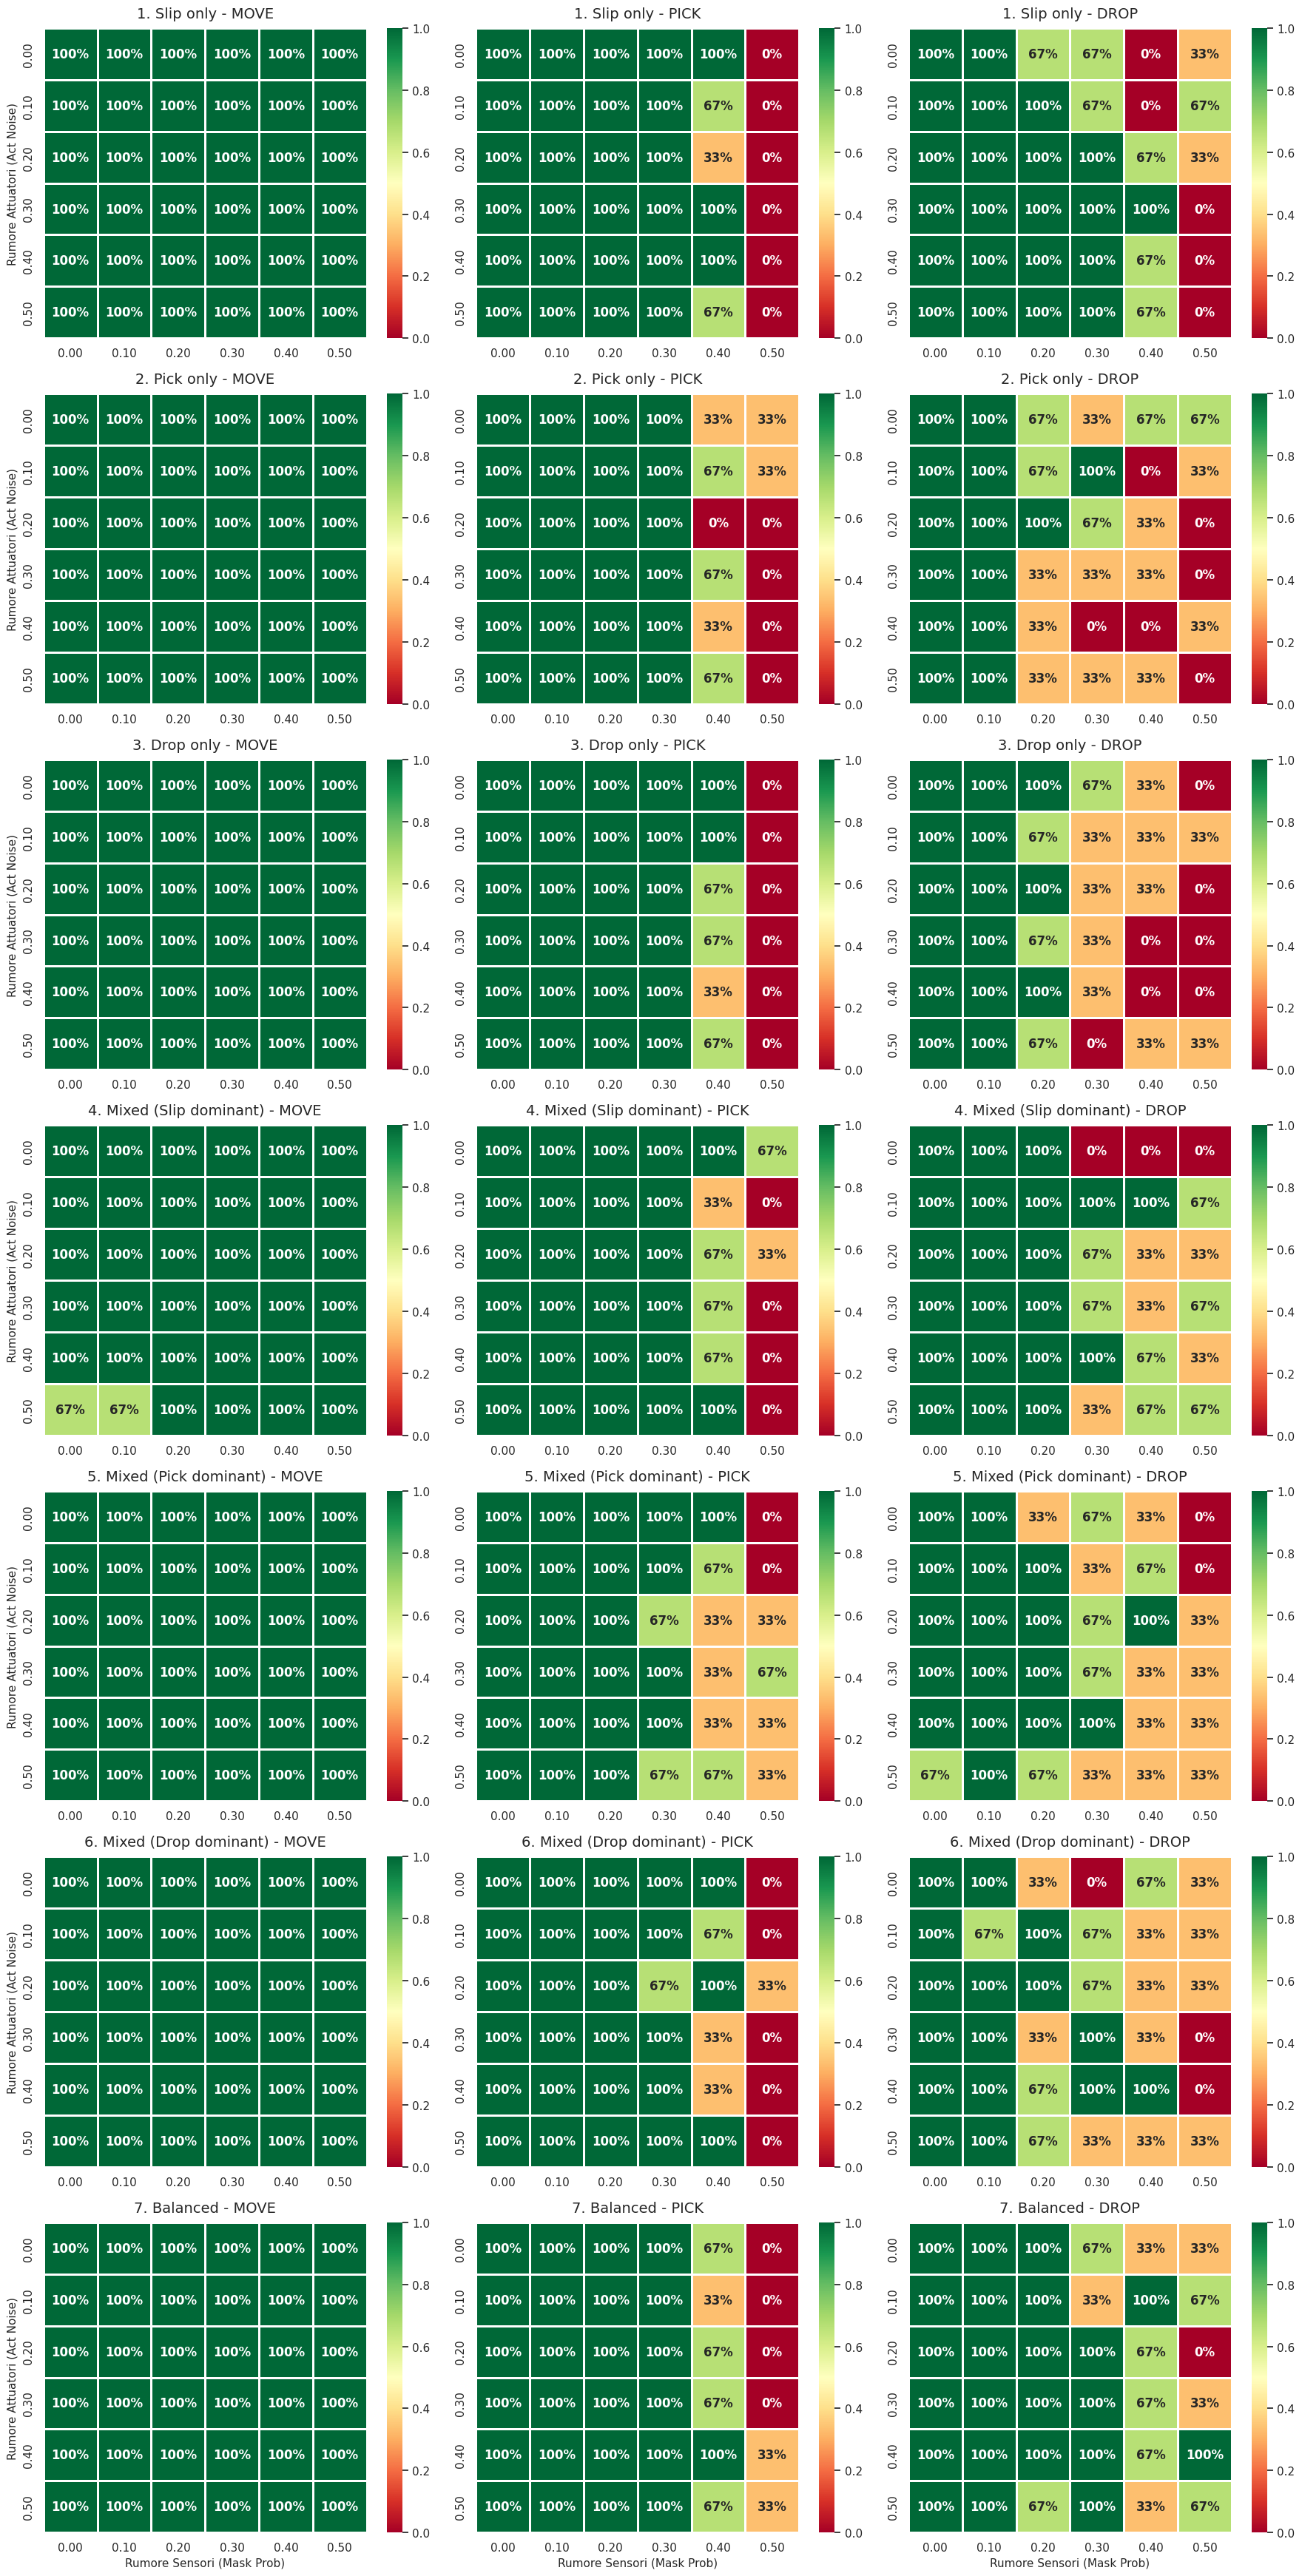

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white")

fig, axes = plt.subplots(7, 3, figsize=(18, 35))
cmap = sns.color_palette("RdYlGn", as_cmap=True)
actions = ['move', 'pick', 'drop']

for row_idx, (scenario_name, dfs) in enumerate(all_grid_results.items()):
    for col_idx, act in enumerate(actions):
        ax = axes[row_idx, col_idx]
        df = dfs[act]

        sns.heatmap(df,
                    cmap=cmap,
                    linewidths=1,
                    linecolor='white',
                    cbar=True,
                    annot=True,
                    fmt=".0%",
                    annot_kws={"size": 12, "weight": "bold"},
                    vmin=0, vmax=1,
                    ax=ax)

        ax.set_title(f"{scenario_name} - {act.upper()}", fontsize=14, pad=10)

        if row_idx == 6:
            ax.set_xlabel("Rumore Sensori (Mask Prob)", fontsize=11)
        if col_idx == 0:
            ax.set_ylabel("Rumore Attuatori (Act Noise)", fontsize=11)

plt.tight_layout()
plt.show()

### **build_mega_grids_and_plot Function**

This function is designed to systematically evaluate how well the PDDL operators (`move`, `pick`, `drop`) can be inferred under various noise conditions (actuator noise and sensor noise) and with increasing training episodes.

#### **Purpose:**

To find the optimal number of training episodes required for the action model learning algorithm to converge, meaning it no longer significantly improves its inference accuracy. It also generates a visual heatmap of the inference success rates across different noise levels.

#### **How it works:**

1.  **Iterative Episode Training:** The function runs experiments with a progressively increasing number of `episodes` (starting from `start_ep` and increasing by `step_ep` up to `max_ep`).
2.  **Parallel Computation:** For each set of `episodes`, it parallelizes the execution of `compute_single_cell` across all combinations of `scenario_noise_funcs`, `action_levels`, and `mask_levels` to efficiently gather data on inference success rates.
3.  **Convergence Check:** After each set of episode runs, it calculates a "graph score" for each scenario/action heatmap (average success rate across all noise combinations). It then compares the current graph scores to the previous ones. If the improvement (`max_improvement`) is below a `threshold` for a specified number of consecutive iterations (`patience`), the algorithm considers itself converged and stops.
4.  **Heatmap Generation:** Once convergence is reached (or `max_ep` is hit), it generates a grid of heatmaps using `seaborn` and `matplotlib`. Each heatmap visualizes the inference success rate for a specific action (`move`, `pick`, `drop`) under varying levels of actuator and sensor noise.

#### **Output:**

A tuple containing:
*   `final_grid_results`: A dictionary containing Pandas DataFrames for each scenario and action, showing the success rates across different noise levels.
*   `optimal_episodes_found`: The number of episodes at which convergence was detected, or the `max_ep` if convergence was not reached.

=== Starting Convergence Search (Optimized Multi-Core CPU) ===
Step: 100 ep. | Tolerance: < 5.0% | Patience: 3 iterations

--- Parallel computation of the entire grid with 1000 episodes ---
[*] Max improvement detected: +100.0% (in graph '1. Slip - move')
[+] Valid improvement! Patience counter reset.
--- Parallel computation of the entire grid with 1100 episodes ---
[*] Max improvement detected: +3.5% (in graph '2. Pick - pick')
[-] No graph exceeded 5.0%. (Patience warning 1/3)
--- Parallel computation of the entire grid with 1200 episodes ---
[*] Max improvement detected: +5.6% (in graph '2. Pick - drop')
[+] Valid improvement! Patience counter reset.
--- Parallel computation of the entire grid with 1300 episodes ---
[*] Max improvement detected: +6.2% (in graph '6. Mixed (Mainly Drop) - drop')
[+] Valid improvement! Patience counter reset.
--- Parallel computation of the entire grid with 1400 episodes ---
[*] Max improvement detected: +4.2% (in graph '5. Mixed (Mainly Pick) - drop'

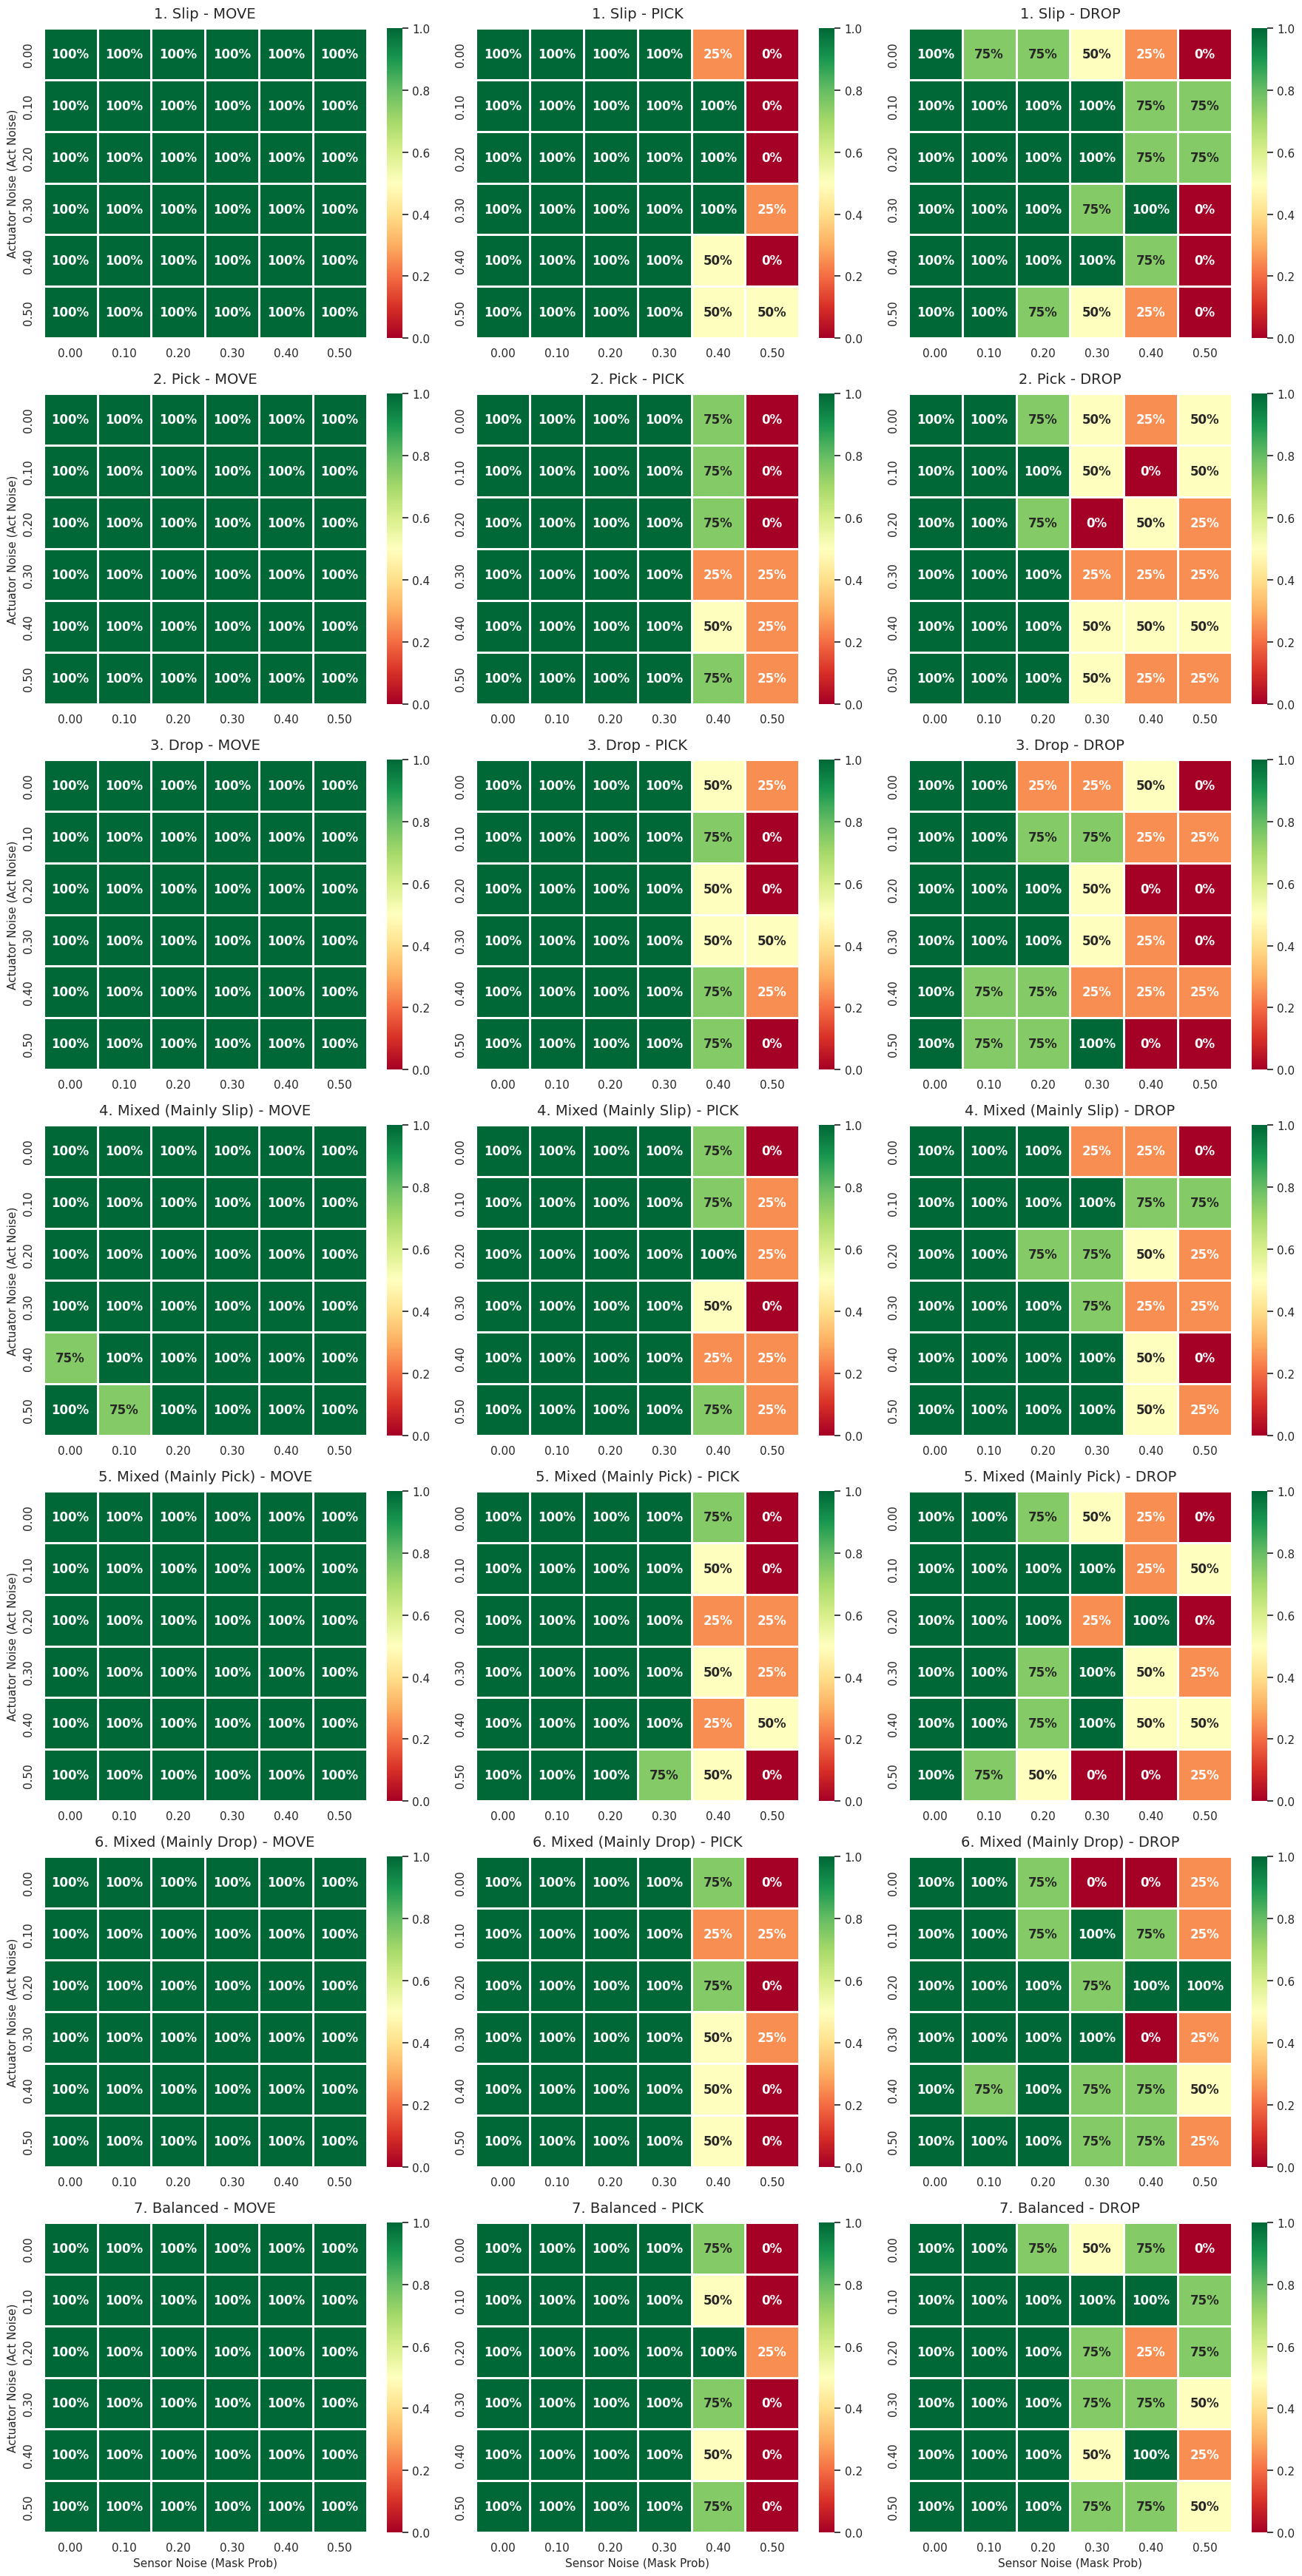

In [ ]:
FISSO_PRE_THRESH = 0.4
FISSO_EFF_THRESH = 0.1
MANUAL_PLAN_EXECS = 80
NUM_EXECUTIONS = 4

mask_levels = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
action_levels = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
actions = ['move', 'pick', 'drop']

scenario_noise_funcs = {
    "1. Slip": lambda a: (a, 0.0, 0.0),
    "2. Pick": lambda a: (0.0, a, 0.0),
    "3. Drop": lambda a: (0.0, 0.0, a),
    "4. Mixed (Mainly Slip)": lambda a: (a*5/3, a*2/3, a*2/3),
    "5. Mixed (Mainly Pick)": lambda a: (a*2/3, a*5/3, a*2/3),
    "6. Mixed (Mainly Drop)": lambda a: (a*2/3, a*2/3, a*5/3),
    "7. Balanced": lambda a: (a, a, a)
}

def compute_single_cell(scenario_name, noise_func, act_noise, mask_noise, ep):
    slip_p, pick_p, drop_p = noise_func(act_noise)
    successi = {'move': 0, 'pick': 0, 'drop': 0}

    for _ in range(NUM_EXECUTIONS):
        _, ops_info, _ = run_experiment(
            slip_prob=slip_p,
            pick_fail_prob=pick_p,
            drop_misplace_prob=drop_p,
            mask_prob=mask_noise,
            pre_thresh=FISSO_PRE_THRESH,
            eff_thresh=FISSO_EFF_THRESH,
            episodes=ep,
            manual_plan_executions=MANUAL_PLAN_EXECS,
            seed=None
        )
        for act in actions:
            if is_strictly_valid(act, ops_info.get(act)):
                successi[act] += 1

    return {
        'scenario': scenario_name,
        'act_noise': act_noise,
        'mask_noise': mask_noise,
        'move_rate': successi['move'] / NUM_EXECUTIONS,
        'pick_rate': successi['pick'] / NUM_EXECUTIONS,
        'drop_rate': successi['drop'] / NUM_EXECUTIONS
    }

def build_mega_grids_and_plot(start_ep, step_ep, max_ep, threshold, patience):
    previous_graph_scores = {(sc_name, act): 0.0 for sc_name in scenario_noise_funcs.keys() for act in actions}
    consecutive_low_improvements = 0
    final_grid_results = None
    optimal_ep = start_ep

    print(f"=== Starting Convergence Search (Optimized Multi-Core CPU) ===")
    print(f"Step: {step_ep} ep. | Tolerance: < {threshold*100}% | Patience: {patience} iterations\n")

    for ep in range(start_ep, max_ep + 1, step_ep):
        print(f"--- Parallel computation of the entire grid with {ep} episodes ---")

        tasks = []
        for scenario_name, noise_func in scenario_noise_funcs.items():
            for act_noise in action_levels:
                for mask_noise in mask_levels:
                    tasks.append(delayed(compute_single_cell)(scenario_name, noise_func, act_noise, mask_noise, ep))

        results = Parallel(n_jobs=-1)(tasks)

        current_grid_results = {
            sc: {act: pd.DataFrame(index=action_levels, columns=mask_levels, dtype=float) for act in actions}
            for sc in scenario_noise_funcs.keys()
        }

        for res in results:
            sc = res['scenario']
            an = res['act_noise']
            mn = res['mask_noise']
            current_grid_results[sc]['move'].loc[an, mn] = res['move_rate']
            current_grid_results[sc]['pick'].loc[an, mn] = res['pick_rate']
            current_grid_results[sc]['drop'].loc[an, mn] = res['drop_rate']

        current_graph_scores = {}
        for scenario_name in scenario_noise_funcs.keys():
            for act in actions:
                df = current_grid_results[scenario_name][act]
                current_graph_scores[(scenario_name, act)] = df.sum().sum() / df.size

        max_improvement = -100.0
        best_improving_graph = None
        for key in current_graph_scores:
            imp = current_graph_scores[key] - previous_graph_scores[key]
            if imp > max_improvement:
                max_improvement = imp
                best_improving_graph = key

        print(f"[*] Max improvement detected: {max_improvement*100:+.1f}% (in graph '{best_improving_graph[0]} - {best_improving_graph[1]}')")

        final_grid_results = current_grid_results
        optimal_ep = ep

        if max_improvement < threshold:
            consecutive_low_improvements += 1
            print(f"[-] No graph exceeded {threshold*100}%. (Patience warning {consecutive_low_improvements}/{patience})")
        else:
            consecutive_low_improvements = 0
            print(f"[+] Valid improvement! Patience counter reset.")

        if consecutive_low_improvements >= patience:
            print(f"\nCONVERGENCE REACHED AT {ep} EPISODES.")
            print(f"For {patience} consecutive steps, no graph out of 21 improved by at least {threshold*100}%")
            break

        previous_graph_scores = current_graph_scores

    print(f"\nGenerating final figure based on optimal {optimal_ep} episodes...")
    sns.set_theme(style="white")
    fig, axes = plt.subplots(7, 3, figsize=(18, 35))
    cmap = sns.color_palette("RdYlGn", as_cmap=True)

    for row_idx, (scenario_name, dfs) in enumerate(final_grid_results.items()):
        for col_idx, act in enumerate(actions):
            ax = axes[row_idx, col_idx]
            df = dfs[act].copy()
            df.index = [f"{x:.2f}" for x in action_levels]
            df.columns = [f"{x:.2f}" for x in mask_levels]
            sns.heatmap(df, cmap=cmap, linewidths=1, linecolor='white', cbar=True, annot=True, fmt=".0%",
                        annot_kws={"size": 12, "weight": "bold"}, vmin=0, vmax=1, ax=ax)
            ax.set_title(f"{scenario_name} - {act.upper()}", fontsize=14, pad=10)
            if row_idx == 6: ax.set_xlabel("Sensor Noise (Mask Prob)", fontsize=11)
            if col_idx == 0: ax.set_ylabel("Actuator Noise (Act Noise)", fontsize=11)

    plt.tight_layout()
    plt.show()
    return final_grid_results, optimal_ep

all_grid_results, optimal_episodes_found = build_mega_grids_and_plot(
    start_ep=1000,
    step_ep=100,
    max_ep=20000,
    threshold=0.05,
    patience=3
)